# 01 Exploration Strategies

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply ε-greedy, UCB, and similar strategies
- Balance exploration and exploitation

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 1, lesson 02 "01. Introduction & Search Algorithms" — BFS, DFS and A* explored a graph whose map you already held; an RL agent has no map, and every step it spends looking around is reward it did not collect.

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 4**.

---


## Lesson Brief

This lesson introduces the big exploration question in reinforcement learning: how should an agent balance trying uncertain actions against using what already looks best?

Students will see several exploration strategies and the intuition behind each one.

Why this matters: poor exploration can make even a correct learning algorithm perform badly.

This lesson gives the decision-making lens needed for the rest of Unit 4.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: the thumbnail Netflix shows you is a bandit arm

Open Netflix and every title carries an image. There is no single image — a title has a set of
candidate artworks, and which one you see is a decision the system makes for you, now, without ever
finding out what would have happened if it had chosen differently.

Netflix described the system in "Artwork Personalization at Netflix" (Netflix Technology Blog, 2017,
by Chandrashekar, Amat, Basilico and Jebara). They use **contextual bandits** rather than a
conventional A/B test, and the reason they give is the reason this whole unit exists: an A/B test
makes you wait — collect a full batch, fit a model, run the test to completion — before any of the
learning is used. A bandit updates and exploits continuously, paying a small, deliberate exploration
cost on every impression instead of one large one up front.

They also solved the problem you will hit the moment you try this at work: how do you evaluate a new
bandit policy without deploying it? Their answer is **replay** — score the new policy only on logged
impressions where it would have made the same choice the production system did, and measure the
"take fraction" on those. The method has a formal guarantee behind it: Li, Chu, Langford and Wang
proved replay is an unbiased offline estimator for contextual bandits (WSDM 2011) and validated it
against live online buckets.

**What goes wrong without this.** Show every user the artwork with the best current estimate and you
never discover a better one, because you never show it. Show artwork at random and you pay for
learning you already did. The bandit run below prices both mistakes in one table.


## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 9: Exploration and Exploitation"**:
[Watch on YouTube](https://www.youtube.com/watch?v=sGuiWX07sKw)

Why this pick:
- Covers the exploration-exploitation dilemma as a central RL problem, not just a coding trick.
- Strong fit for the opening lesson of this unit.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: the reward lost because the best action was not always chosen.
- Bandit setting: choose an action and get reward, without a full state-transition story.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?
- Why is a bandit a useful teaching simplification before full RL exploration?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.
- Thinking bandit exploration and full RL exploration are exactly the same problem.


## Big Idea

Exploration asks: *Should the agent try something uncertain?*

Exploitation asks: *Should the agent use what currently looks best?*

This notebook introduces the main family of strategies used to balance those two goals.

## Why This Notebook Starts with Bandits

Students sometimes ask why exploration is first explained with a bandit instead of a full MDP.

### The reason

Bandits isolate the exploration-exploitation dilemma very clearly.

- choose an action
- observe a reward
- update your belief about that action

There is no full state-transition chain yet.
That makes it easier to see the decision trade-off before adding the extra difficulty of long-term trajectories.

### What changes in full RL?

In full reinforcement learning, exploration matters even more because actions also change future states.
So the same basic dilemma remains, but the consequences are longer-term and more complicated.

### Teaching takeaway

This notebook teaches the **core intuition** first.
Later RL settings keep the same dilemma, but with more structure around states, trajectories, and delayed effects.

## Learning Path in This Notebook

1. Review the dilemma
2. Compare several exploration strategies conceptually
3. Run a bandit simulation
4. Interpret reward and regret curves

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nUnit 4 - Exploration Strategies")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


✅ Libraries imported!

Unit 4 - Exploration Strategies


## Concept Map

- **Epsilon-greedy**: simple random exploration with probability epsilon
- **UCB**: prefers actions with high estimated value *and* high uncertainty
- **Thompson Sampling**: samples from a belief distribution over action quality
- **Curiosity / intrinsic motivation**: rewards novelty or prediction error

### Step Guide

**What this cell does:** Build the next chunk of the lesson (often a function, table, or training loop).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Save a value in a name so the next lines can read it.
strategies = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "epsilon-greedy": "random exploration with fixed or decaying epsilon",
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "UCB": "optimism under uncertainty",
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "Thompson Sampling": "sample from posterior beliefs",
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "curiosity": "reward novelty or prediction error",
# Part of a dict/set literal layout (syntax grouping).
}

# Start a loop: repeat the indented block once per item in the sequence.
for name, description in strategies.items():
    # Show text or numbers in the cell output area under the code.
    print(f"- {name}: {description}")


- epsilon-greedy: random exploration with fixed or decaying epsilon
- UCB: optimism under uncertainty
- Thompson Sampling: sample from posterior beliefs
- curiosity: reward novelty or prediction error


## What to watch for in the simulation

When you run the example below, ask:

- Which strategy finds the best arm fastest?
- Which strategy wastes the least reward early on?
- Which strategy seems most stable over time?

That is the lens you will later apply in larger RL environments.

## Note

This notebook uses a bandit example because it isolates exploration clearly before
mixing it with value functions, long episodes, and full environment dynamics.

## 🌍 Industry-Motivated Worked Example — A/B Testing with Multi-Armed Bandits

> **What is real here and what is not.** The industry uses below are real, and the
> stochastic reward is real in kind: each simulated visitor converts or does not, one draw at
> a time, exactly as in a live experiment. The underlying conversion rates are chosen by us
> and hidden from the algorithms — which is what lets us grade whether each method found the
> best variant. No company's traffic data is used.

**Industry context:**
- Streaming, ads, and product teams do use bandit-style ideas in experimentation
- The exact production systems are usually more complex than the small classroom version shown here
- Treat these examples as realistic application families, not as one-to-one replicas of a company's production stack

We compare **ε-greedy**, **UCB**, and **Thompson Sampling** on a **simulated** A/B test. The conversion rates are numbers we chose and then hid from the algorithms, so we can check afterwards whether each method actually found the best variant — something you can never verify on live traffic. The *randomness* is the real part: each visitor converts or does not, exactly as in a real experiment.

**Heads-up (preview):** this lesson only teaches ε-greedy properly. The `ucb()` and `thompson()` functions in the next cell are **previews** whose internals are taught in lessons 02–03 — for now, read only their reward/regret curves and treat the two names as "smarter exploration, explained soon".

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


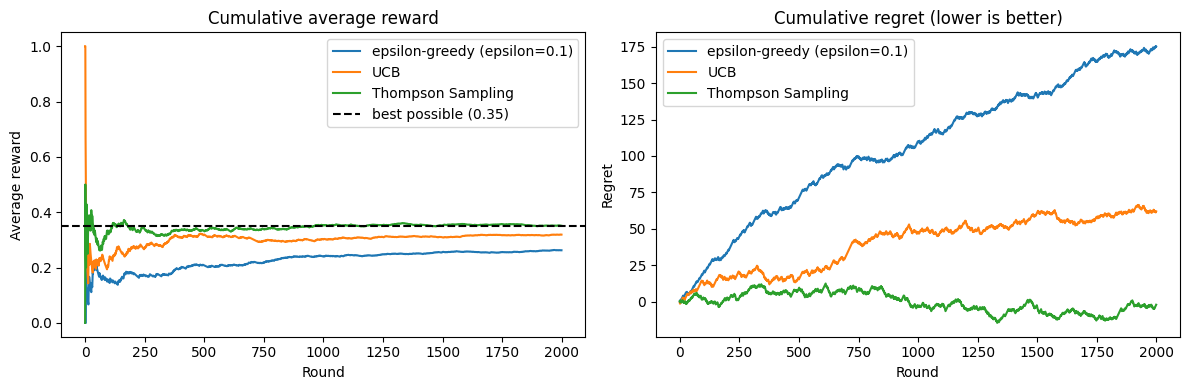

epsilon-greedy (epsilon=0.1): total reward = 525, final avg reward = 0.263
UCB: total reward = 638, final avg reward = 0.319
Thompson Sampling: total reward = 702, final avg reward = 0.351


In [3]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# Save a value in a name so the next lines can read it.
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]
# Another assignment—same idea: store a value for the lines below.
N_ARMS = len(TRUE_RATES)
# Another assignment—same idea: store a value for the lines below.
N_ROUNDS = 2000
# Another assignment—same idea: store a value for the lines below.
BEST_RATE = max(TRUE_RATES)


# Function `pull` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: arm.
def pull(arm):
    # Send a value back to whoever called this function.
    return 1 if np.random.rand() < TRUE_RATES[arm] else 0


# Function `epsilon_greedy` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: eps.
def epsilon_greedy(eps):
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS)
    # Another assignment—same idea: store a value for the lines below.
    totals = np.zeros(N_ARMS)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        arm = np.random.randint(N_ARMS) if np.random.rand() < eps else np.argmax(totals / (counts + 1e-9))
        # Unpack the one-step model output from transition(state, action).
        reward = pull(arm)
        # Save a value in a name so the next lines can read it.
        counts[arm] += 1
        # Another assignment—same idea: store a value for the lines below.
        totals[arm] += reward
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(reward)
    # Send a value back to whoever called this function.
    return np.array(rewards)


# Function `ucb` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def ucb():
    # Save a value in a name so the next lines can read it.
    counts = np.zeros(N_ARMS)
    # Another assignment—same idea: store a value for the lines below.
    totals = np.zeros(N_ARMS)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for arm in range(N_ARMS):
        # Unpack the one-step model output from transition(state, action).
        reward = pull(arm)
        # Save a value in a name so the next lines can read it.
        counts[arm] = 1
        # Another assignment—same idea: store a value for the lines below.
        totals[arm] += reward
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(reward)
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(N_ARMS, N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        ucb_vals = totals / counts + np.sqrt(2 * np.log(t + 1) / counts)
        # Another assignment—same idea: store a value for the lines below.
        arm = np.argmax(ucb_vals)
        # Unpack the one-step model output from transition(state, action).
        reward = pull(arm)
        # Save a value in a name so the next lines can read it.
        counts[arm] += 1
        # Another assignment—same idea: store a value for the lines below.
        totals[arm] += reward
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(reward)
    # Send a value back to whoever called this function.
    return np.array(rewards)


# Function `thompson` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: no named parameters in the signature.
def thompson():
    # Save a value in a name so the next lines can read it.
    alpha = np.ones(N_ARMS)
    # Another assignment—same idea: store a value for the lines below.
    beta_ = np.ones(N_ARMS)
    # Unpack the one-step model output from transition(state, action).
    rewards = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(N_ROUNDS):
        # Save a value in a name so the next lines can read it.
        samples = np.random.beta(alpha, beta_)
        # Another assignment—same idea: store a value for the lines below.
        arm = np.argmax(samples)
        # Unpack the one-step model output from transition(state, action).
        reward = pull(arm)
        # If the condition is True, run the indented block under this line.
        if reward:
            # Save a value in a name so the next lines can read it.
            alpha[arm] += 1
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Save a value in a name so the next lines can read it.
            beta_[arm] += 1
        # Add one new item to the end of a list (the list grows in place).
        rewards.append(reward)
    # Send a value back to whoever called this function.
    return np.array(rewards)


# Save a value in a name so the next lines can read it.
strategies = {
    # Another assignment—same idea: store a value for the lines below.
    "epsilon-greedy (epsilon=0.1)": epsilon_greedy(0.1),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "UCB": ucb(),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "Thompson Sampling": thompson(),
# Part of a dict/set literal layout (syntax grouping).
}


# Function `cumulative_average` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: values.
def cumulative_average(values):
    # Send a value back to whoever called this function.
    return np.cumsum(values) / np.arange(1, len(values) + 1)


# Function `cumulative_regret` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: values.
def cumulative_regret(values):
    # Send a value back to whoever called this function.
    return np.cumsum(BEST_RATE - values)


# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(12, 4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1, 2, 1)
# Start a loop: repeat the indented block once per item in the sequence.
for name, rewards in strategies.items():
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(cumulative_average(rewards), label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(BEST_RATE, color="k", linestyle="--", label=f"best possible ({BEST_RATE})")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative average reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Round")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Average reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.subplot(1, 2, 2)
# Start a loop: repeat the indented block once per item in the sequence.
for name, rewards in strategies.items():
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.plot(cumulative_regret(rewards), label=name)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Cumulative regret (lower is better)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Round")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Regret")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Start a loop: repeat the indented block once per item in the sequence.
for name, rewards in strategies.items():
    # Show text or numbers in the cell output area under the code.
    print(f"{name}: total reward = {int(rewards.sum())}, final avg reward = {rewards.mean():.3f}")


## 💬 Discuss

The measured run: **ε-greedy (ε=0.1) total reward 525**, **UCB 638**, **Thompson Sampling 702**, over
the same arms and the same number of rounds. Argue these out.

1. Thompson beat UCB by 64 and ε-greedy by 177 on this run. What is the strongest claim those three
   numbers actually support — and what claim is a colleague making if they write "Thompson Sampling
   is the best exploration strategy"? (Lesson 05 of this unit runs the same question 50 times.
   Predict the answer now.)
2. All three algorithms saw identical arms. So the 177-point gap between the best and worst is
   entirely a cost of *how* they explored, not of what was available. Where did ε-greedy's 177 points
   go? Name the specific behaviour, and say what would have to be true about the arms for ε-greedy to
   close the gap.
3. Netflix pays its exploration cost on real users watching real evenings. Suppose the "arms" are
   which of three Arabic-language onboarding flows a Saudi telecom shows new subscribers. Who bears
   the exploration cost, and is that acceptable? Now change the arms to three loan-approval
   thresholds and answer again — and explain what changed in your reasoning.


## 📝 Summary

In this notebook, you learned:
- The **exploration-exploitation trade-off**: why an agent must try new actions to discover better long-term rewards
- **ε-greedy**: take random actions with probability ε, exploit the best known action otherwise (this notebook keeps ε fixed at 0.1; decay schedules were covered in Unit 1, lesson 05)
- **Upper Confidence Bound (UCB)**: select actions based on both estimated value and uncertainty, ensuring optimism in the face of uncertainty
- **Thompson Sampling**: maintain a probability distribution over each action's value and sample from it to drive exploration

**Next steps:** Apply these exploration strategies inside a full DQN/PPO training loop and observe their effect on sample efficiency in Unit 4 exercises.

In [4]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2, Multi-armed Bandits.
2. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
3. Russo, D., Van Roy, B., Kazerouni, A., Osband, I. & Wen, Z. (2018). *A Tutorial on Thompson Sampling*. Foundations and Trends in Machine Learning, 11(1), 1-96. <https://arxiv.org/abs/1707.02038>
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>
"""))

## 📚 References

1. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2, Multi-armed Bandits.
2. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
3. Russo, D., Van Roy, B., Kazerouni, A., Osband, I. & Wen, Z. (2018). *A Tutorial on Thompson Sampling*. Foundations and Trends in Machine Learning, 11(1), 1-96. <https://arxiv.org/abs/1707.02038>
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


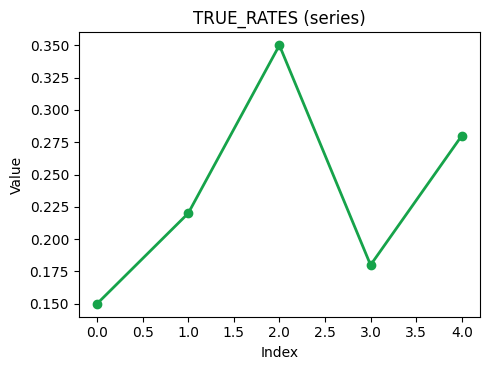

In [5]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## ⚠️ Where this breaks

**The assumption that has to hold:** your action does not change the state of the world. A bandit has
no transitions — that is the entire difference between this unit and the rest of the course.

- **Bandits ignore consequences.** Showing artwork does not change which titles exist. Recommending a
  video *does* change what the user watches next, what the system logs, and what it will recommend
  tomorrow. When your action changes the state, you have an MDP wearing a bandit's clothes, and a
  bandit will optimise the immediate click while degrading the sequence. That is the mechanism behind
  filter bubbles, and it is invisible in every metric a bandit reports.
- **Stationary arms are an assumption, not a fact.** These arms have fixed payoff probabilities. A
  news article goes stale, a promotion saturates, a competitor reacts. Any strategy that converges —
  which is all of them — is by construction slow to notice that the world moved.
- **A single run cannot rank close strategies.** 638 against 702 is one sample of a random process.
  Every notebook in this unit says so; lesson 05 measures how often the ranking flips.
- **Exploration is a real cost paid by real people.** In a simulation, pulling a bad arm costs a
  number. In production it costs a worse recommendation, a worse price or a worse clinical decision.
  Some settings do not permit deliberate randomisation at all, whatever the mathematics says.
- **Cheaper alternative:** if you need one decision, have plenty of traffic and need a result a
  statistician or a regulator can audit, a fixed-split A/B test with a pre-registered stopping rule is
  simpler and more defensible. Bandits earn their keep when there are *many* decisions to make
  repeatedly, and when the cost of the learning period is the thing you are trying to reduce.


## Closing Takeaway

**Teaching takeaway:** Exploration strategies determine how an agent gathers useful information before it becomes confident in one choice.

**If students remember one idea:** Exploration is part of the learning algorithm, not an optional extra.

**Quick check before moving on:**
- Can you explain why a purely greedy agent can get stuck with poor knowledge?
- Can you describe how different exploration rules change the data an agent collects?

**Bridge to the next step:** The next lesson focuses on how to balance exploration with exploitation instead of treating them as separate ideas.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=10 | term=True | trunc=False


objc[66232]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1148f8138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114df49c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[66232]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1148f8188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114df4a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[66232]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1148f7c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114df4a68). T

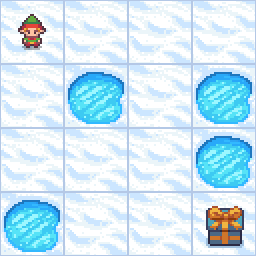

In [6]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
